# GNN Blockchain Anomaly Detection — Fixed Pipeline
## Elliptic Bitcoin Dataset | 4 Models × 3 Settings | 10 Optuna Trials


In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('torch-geometric')
install('kagglehub')
install('optuna')
install('tqdm')
print('All packages installed.')


All packages installed.


In [ ]:
import os, gc, random, inspect, warnings, json, pickle
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import (
    GCNConv, GATConv, GATv2Conv, SAGEConv,
    GraphNorm, GINConv, TransformerConv,
)

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve,
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


In [ ]:
DATA_DIR = 'datasets/elliptic'
os.makedirs(DATA_DIR, exist_ok=True)

needed = [
    'elliptic_txs_features.csv',
    'elliptic_txs_edgelist.csv',
    'elliptic_txs_classes.csv',
]

if not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in needed):
    try:
        import kagglehub, shutil
        from pathlib import Path
        src = Path(kagglehub.dataset_download('ellipticco/elliptic-data-set'))
        for name in needed:
            hits = list(src.rglob(name))
            if hits:
                shutil.copy2(hits[0], os.path.join(DATA_DIR, name))
            else:
                raise FileNotFoundError(f'{name} not found')
        print(f'Downloaded to {DATA_DIR}')
    except Exception as e:
        print(f'Auto-download failed: {e}')
        print('Manually place the 3 CSVs in', DATA_DIR)
else:
    print('Dataset already present.')


Using Colab cache for faster access to the 'elliptic-data-set' dataset.
Downloaded to datasets/elliptic


In [ ]:
feat_df  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv', header=None)
edge_df  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
class_df = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')

# column 0 = txId, column 1 = time_step, columns 2-166 = 165 features
feat_df = feat_df.rename(columns={0: 'txId', 1: 'time_step'})

print(f'Nodes: {len(feat_df):,}  |  Edges: {len(edge_df):,}  |  Features: {feat_df.shape[1]-2}')
print('Raw class distribution:')
print(class_df['class'].value_counts().to_string())


Nodes: 203,769  |  Edges: 234,355  |  Features: 165
Raw class distribution:
class
unknown    157205
2           42019
1            4545


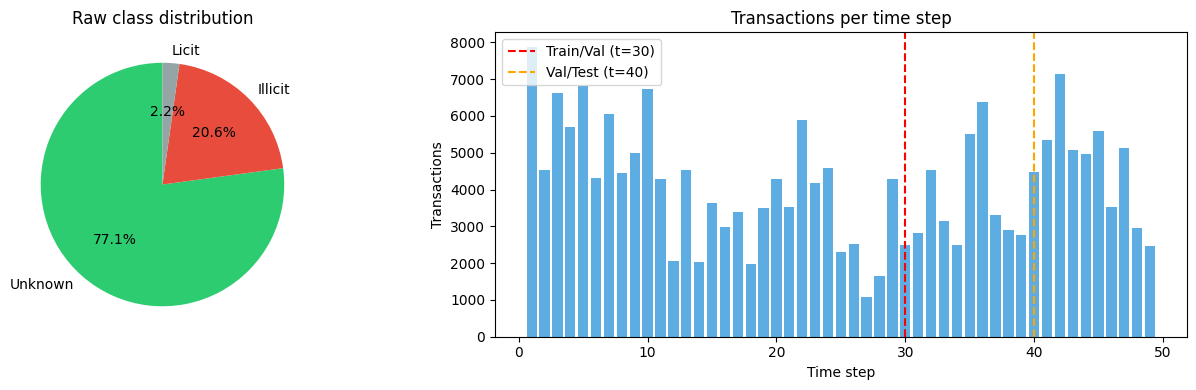

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lmap = {'1': 'Licit', '2': 'Illicit', 'unknown': 'Unknown'}
class_df['label_name'] = class_df['class'].map(lmap)
counts = class_df['label_name'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#95a5a6'], startangle=90)
axes[0].set_title('Raw class distribution')

tc = feat_df['time_step'].value_counts().sort_index()
axes[1].bar(tc.index, tc.values, color='#3498db', alpha=0.8)
axes[1].axvline(30, color='red',    linestyle='--', label='Train/Val (t=30)')
axes[1].axvline(40, color='orange', linestyle='--', label='Val/Test (t=40)')
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('Transactions')
axes[1].set_title('Transactions per time step'); axes[1].legend()
plt.tight_layout(); plt.show()


In [ ]:
# ── CLASS_MAP: illicit (raw '2') → label 1  (POSITIVE / minority)
#              licit   (raw '1') → label 0  (negative / majority)
#              unknown            → label 2  (excluded from masks, kept in graph)
#
# CRITICAL: illicit is the class we want to detect (positive class).
# probs[:, 1] = illicit probability throughout all metrics.
# CORRECT:
CLASS_MAP = {'unknown': 2, '1': 1, '2': 0}
TIME_SPLITS = [30, 40]

feat_array = feat_df.loc[:, 'time_step':].values
features   = torch.tensor(feat_array, dtype=torch.float)

labels_mapped = class_df['class'].map(CLASS_MAP)
labels        = torch.tensor(labels_mapped.values, dtype=torch.long)

# Node ID → contiguous integer mapping
nodes  = feat_df['txId']
map_id = {j: i for i, j in enumerate(nodes)}

# Undirected edges (add reverse + deduplicate + remove self-loops)
edges     = edge_df[['txId1', 'txId2']].copy()
edges_rev = edges.rename(columns={'txId1': 'txId2', 'txId2': 'txId1'})
edges     = pd.concat([edges, edges_rev], ignore_index=True)
edges['txId1'] = edges['txId1'].map(map_id)
edges['txId2'] = edges['txId2'].map(map_id)
edges = edges.dropna().astype(int)
edges = edges[edges['txId1'] != edges['txId2']]
edges = edges.drop_duplicates().reset_index(drop=True)
edge_index = torch.tensor(edges.values.T, dtype=torch.long)

# Temporal masks (known only)
time_step = torch.tensor(feat_df['time_step'].values, dtype=torch.long)
known     = labels != 2

train_mask = (time_step <  TIME_SPLITS[0]) & known
val_mask   = (time_step >= TIME_SPLITS[0]) & (time_step < TIME_SPLITS[1]) & known
test_mask  = (time_step >= TIME_SPLITS[1]) & known

# Drop time_step column → 165 features
x    = features[:, 1:]
data = Data(x=x, y=labels, edge_index=edge_index)
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

# ── Sanity checks ──────────────────────────────────────────────────────────────
assert data.x.shape[1] == 165, f'Expected 165 features, got {data.x.shape[1]}'
assert not torch.logical_and(train_mask, val_mask).any(),  'Train/Val overlap!'
assert not torch.logical_and(train_mask, test_mask).any(), 'Train/Test overlap!'
assert not torch.logical_and(val_mask,   test_mask).any(), 'Val/Test overlap!'

n_illicit_train = (labels[train_mask] == 1).sum().item()
n_licit_train   = (labels[train_mask] == 0).sum().item()
assert n_illicit_train < n_licit_train, \
    f'illicit ({n_illicit_train}) should be minority vs licit ({n_licit_train})'

print('Graph constructed and all sanity checks passed.')
print(f'  Nodes: {data.num_nodes:,}  |  Edges: {data.num_edges:,}  |  Features: {data.num_features}')
print()
for name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    ys = labels[mask]
    ni = (ys == 1).sum().item()  # illicit = label 1
    nl = (ys == 0).sum().item()  # licit   = label 0
    tot = mask.sum().item()
    print(f'  {name}: {tot:,} nodes | illicit={ni} ({ni/tot*100:.1f}%) | licit={nl} ({nl/tot*100:.1f}%)')


Graph constructed and all sanity checks passed.
  Nodes: 203,769  |  Edges: 468,710  |  Features: 165

  Train: 26,381 nodes | illicit=2871 (10.9%) | licit=23510 (89.1%)
  Val: 8,999 nodes | illicit=1038 (11.5%) | licit=7961 (88.5%)
  Test: 11,184 nodes | illicit=636 (5.7%) | licit=10548 (94.3%)


In [ ]:
# ── Weighted CrossEntropyLoss ──────────────────────────────────────────────
# Weights computed from TRAINING labels only (no leakage).
# illicit = label 1 = minority → upweighted (w > 1)
# licit   = label 0 = majority → downweighted (w < 1)
y_train   = labels[train_mask]
n_illicit = (y_train == 1).sum().item()
n_licit   = (y_train == 0).sum().item()
n_total   = n_illicit + n_licit

w_licit   = n_total / (2 * n_licit)
w_illicit = n_total / (2 * n_illicit)
class_weights = torch.tensor([w_licit, w_illicit])

assert class_weights[1] > class_weights[0], \
    'illicit weight must be higher than licit weight'

print(f'Class weights:')
print(f'  licit   (label 0): {w_licit:.4f}  (majority, downweighted)')
print(f'  illicit (label 1): {w_illicit:.4f}  (minority, upweighted)')
print(f'  Ratio illicit/licit: {w_illicit/w_licit:.2f}x')


Class weights:
  licit   (label 0): 0.5611  (majority, downweighted)
  illicit (label 1): 4.5944  (minority, upweighted)
  Ratio illicit/licit: 8.19x


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# MODEL DEFINITIONS
# ════════════════════════════════════════════════════════════════════════

def _init_out(out, init_mode):
    """Shared output layer initialisation for all models."""
    if out is None: return
    if init_mode == 'xavier':
        nn.init.xavier_uniform_(out.weight)
        nn.init.zeros_(out.bias)
    elif init_mode == 'default':
        out.reset_parameters()


class GCN(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier'):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        dims = [in_channels] + [hidden_dim]*(num_layers-1) + [embedding_dim]
        for i in range(num_layers):

            self.convs.append(GCNConv(dims[i], dims[i+1], cached=False))
            if graphnorm and i < num_layers - 1:
                self.gns.append(GraphNorm(dims[i+1]))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GAT(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 n_heads=4, negative_slope=0.2):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        if num_layers == 1:

            self.convs.append(GATConv(in_channels, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))
        else:
            self.convs.append(GATConv(in_channels, hidden_dim,
                heads=n_heads, concat=True, dropout=0.0,
                negative_slope=negative_slope))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            for _ in range(num_layers - 2):
                self.convs.append(GATConv(hidden_dim * n_heads, hidden_dim,
                    heads=n_heads, concat=True, dropout=0.0,
                    negative_slope=negative_slope))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            self.convs.append(GATConv(hidden_dim * n_heads, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GATv2(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 n_heads=4, negative_slope=0.2):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        if num_layers == 1:
            self.convs.append(GATv2Conv(in_channels, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))
        else:
            self.convs.append(GATv2Conv(in_channels, hidden_dim,
                heads=n_heads, concat=True, dropout=0.0,
                negative_slope=negative_slope))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            for _ in range(num_layers - 2):
                self.convs.append(GATv2Conv(hidden_dim * n_heads, hidden_dim,
                    heads=n_heads, concat=True, dropout=0.0,
                    negative_slope=negative_slope))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            self.convs.append(GATv2Conv(hidden_dim * n_heads, embedding_dim,
                heads=1, concat=False, dropout=0.0,
                negative_slope=negative_slope))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class SAGE(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 aggregator='mean'):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        dims = [in_channels] + [hidden_dim]*(num_layers-1) + [embedding_dim]
        for i in range(num_layers):
            self.convs.append(SAGEConv(dims[i], dims[i+1], aggr=aggregator))
            if graphnorm and i < num_layers - 1:
                self.gns.append(GraphNorm(dims[i+1]))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GIN(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier'):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        def _mlp(in_ch, out_ch):
            if graphnorm:
                return nn.Sequential(
                    nn.Linear(in_ch, out_ch),
                    nn.ReLU(),
                    nn.Linear(out_ch, out_ch),
                )
            else:
                return nn.Sequential(
                    nn.Linear(in_ch, out_ch),
                    nn.BatchNorm1d(out_ch),
                    nn.ReLU(),
                    nn.Linear(out_ch, out_ch),
                )

        if num_layers == 1:
            self.convs.append(GINConv(_mlp(in_channels, embedding_dim), train_eps=False))
        else:
            self.convs.append(GINConv(_mlp(in_channels, hidden_dim), train_eps=False))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim))
            for _ in range(num_layers - 2):
                self.convs.append(GINConv(_mlp(hidden_dim, hidden_dim), train_eps=False))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim))
            self.convs.append(GINConv(_mlp(hidden_dim, embedding_dim), train_eps=False))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs:
            for m in conv.nn.modules():
                if hasattr(m, 'reset_parameters'):
                    m.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


class GraphTransformer(nn.Module):
    def __init__(self, in_channels, hidden_dim, embedding_dim, output_dim=2,
                 num_layers=2, dropout=0.5, graphnorm=False, init_mode='xavier',
                 n_heads=4):
        super().__init__()
        assert num_layers >= 1
        self.convs = nn.ModuleList()
        self.gns   = nn.ModuleList() if graphnorm else None
        self.graphnorm = graphnorm
        self.dropout   = dropout
        self.init_mode = init_mode

        if num_layers == 1:
            self.convs.append(TransformerConv(
                in_channels, embedding_dim, heads=1, concat=False,
                dropout=0.0, beta=True))
        else:
            self.convs.append(TransformerConv(
                in_channels, hidden_dim, heads=n_heads, concat=True,
                dropout=0.0, beta=True))
            if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            for _ in range(num_layers - 2):
                self.convs.append(TransformerConv(
                    hidden_dim * n_heads, hidden_dim, heads=n_heads, concat=True,
                    dropout=0.0, beta=True))
                if graphnorm: self.gns.append(GraphNorm(hidden_dim * n_heads))
            self.convs.append(TransformerConv(
                hidden_dim * n_heads, embedding_dim, heads=1, concat=False,
                dropout=0.0, beta=True))

        self.out = nn.Linear(embedding_dim, output_dim)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs: conv.reset_parameters()
        if self.graphnorm:
            for gn in self.gns: gn.reset_parameters()
        _init_out(self.out, self.init_mode)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:

                if self.graphnorm: x = self.gns[i](x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)


MODEL_REGISTRY = {
    'GCN':    GCN,
    'GAT':    GAT,
    'GATv2':  GATv2,
    'SAGE':   SAGE,
    'GIN':    GIN,
    'GTRANS': GraphTransformer,
}

print('Models defined:', list(MODEL_REGISTRY.keys()))


Models defined: ['GCN', 'GAT', 'GATv2', 'SAGE', 'GIN', 'GTRANS']


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION UTILITIES
# ════════════════════════════════════════════════════════════════════════

def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def train_and_evaluate(model, data, train_mask, val_mask, test_mask,
                       lr, n_epochs, weight_decay, device, class_weights,
                       verbose=False):
    """Train model, track best val-AUPRC epoch, restore best weights, evaluate test.

    Positive class = illicit = label 1. probs[:, 1] = illicit probability.
    Uses weighted CrossEntropyLoss throughout.
    Saves best_model_state whenever val AUPRC improves; restores at end.
    """
    model      = model.to(device)
    data       = data.to(device)
    train_mask = train_mask.to(device)

    if val_mask is not None and test_mask is not None:
        assert not torch.logical_and(
            val_mask.bool().to(device), test_mask.bool().to(device)).any(), \
            'val_mask and test_mask must be disjoint'

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_scores, val_losses = [], [], []
    best_val_auprc   = 0.0
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = criterion(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            if val_mask is not None and val_mask.to(device).sum() > 0:
                vm       = val_mask.to(device)
                logits_v = out[vm]
                probs_v  = logits_v.softmax(dim=1)
                y_v      = data.y[vm]
                v_loss   = criterion(logits_v, y_v).item()
                val_losses.append(v_loss)
                try:

                    ap = average_precision_score(
                        y_v.cpu().numpy(), probs_v[:, 1].cpu().numpy())
                except Exception:
                    ap = 0.0
                val_scores.append(ap)
                if ap > best_val_auprc:
                    best_val_auprc   = ap
                    best_model_state = {k: v.cpu().clone()
                                        for k, v in model.state_dict().items()}
            else:
                val_scores.append(None)
                val_losses.append(None)

        if verbose and (epoch + 1) % 50 == 0:
            vs = val_scores[-1]
            if vs is not None:
                print(f'  Epoch {epoch+1:3d}/{n_epochs} | '
                      f'Loss: {loss.item():.4f} | Val AUPRC: {vs:.4f}')
            else:
                print(f'  Epoch {epoch+1:3d}/{n_epochs} | Loss: {loss.item():.4f}')


    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})


    model.eval()
    with torch.no_grad():
        out    = model(data.x, data.edge_index)
        tm     = test_mask.to(device)
        probs  = out[tm].softmax(dim=1)
        y_test = data.y[tm].cpu().numpy()
        p_test = probs[:, 1].cpu().numpy()
        test_auprc = average_precision_score(y_test, p_test)
        test_auroc = roc_auc_score(y_test, p_test)

    return {
        'model':          model,
        'train_losses':   train_losses,
        'val_scores':     val_scores,
        'val_losses':     val_losses,
        'best_val_auprc': best_val_auprc,
        'test_auprc':     test_auprc,
        'test_auroc':     test_auroc,
        'test_probs':     p_test,
        'test_labels':    y_test,
    }


def evaluate_test(model, data, test_mask, device,
                  percentile_q_list=[90, 99, 99.9]):
    """Single-pass full test set evaluation. probs[:, 1] = illicit probability."""
    model.eval()
    with torch.no_grad():
        out    = model(data.x.to(device), data.edge_index.to(device))
        tm     = test_mask.to(device)
        probs  = out[tm].softmax(dim=1)
        y_test = data.y[tm].cpu().numpy()
        p_test = probs[:, 1].cpu().numpy()

    auroc = roc_auc_score(y_test, p_test)
    auprc = average_precision_score(y_test, p_test)
    prec_c, rec_c, _ = precision_recall_curve(y_test, p_test)

    res = {
        'test_auroc':  auroc,
        'test_auprc':  auprc,
        'test_probs':  p_test,
        'test_labels': y_test,
        'pr_prec':     prec_c,
        'pr_recall':   rec_c,
    }
    for q in percentile_q_list:
        cutoff = np.percentile(p_test, q)
        y_hard = (p_test >= cutoff).astype(int)
        res[f'precision_at_{q}'] = precision_score(y_test, y_hard, zero_division=0)
        res[f'recall_at_{q}']    = recall_score(y_test, y_hard,    zero_division=0)
        res[f'f1_at_{q}']        = f1_score(y_test, y_hard,        zero_division=0)
    return res


def build_model(model_name, in_channels, hparams, graphnorm, init_mode):
    cls    = MODEL_REGISTRY[model_name]
    kwargs = {
        'in_channels':   in_channels,
        'hidden_dim':    hparams['hidden_dim'],
        'embedding_dim': hparams['embedding_dim'],
        'output_dim':    2,
        'num_layers':    hparams['num_layers'],
        'dropout':       hparams['dropout'],
        'graphnorm':     graphnorm,
        'init_mode':     init_mode,
    }
    if model_name == 'SAGE':
        kwargs['aggregator'] = hparams.get('aggregator', 'mean')
    if model_name in ('GTRANS', 'GAT', 'GATv2'):
        kwargs['n_heads'] = hparams.get('n_heads', 4)
    sig    = inspect.signature(cls.__init__)
    kwargs = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return cls(**kwargs)


print('Utilities defined.')


Utilities defined.


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION
# ════════════════════════════════════════════════════════════════════════

N_TRIALS = 10

EXPERIMENT_SETTINGS = {
    'baseline':         {'graphnorm': False, 'init_mode': 'default'},
    'xavier_only':      {'graphnorm': False, 'init_mode': 'xavier'},
    'graphnorm_xavier': {'graphnorm': True,  'init_mode': 'xavier'},
}
MODEL_NAMES = ['GCN', 'GAT', 'GATv2', 'SAGE']
WEIGHT_DECAY_DEFAULT = 5e-4

# Move data to device once
data_device = data.to(DEVICE)
train_mask_d = data.train_mask.to(DEVICE)
val_mask_d   = data.val_mask.to(DEVICE)
test_mask_d  = data.test_mask.to(DEVICE)

all_results = {}

COLORS = {
    'GCN': '#1f77b4', 'GAT': '#ff7f0e', 'GATv2': '#17becf',
    'SAGE': '#2ca02c',
}

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results_csv', exist_ok=True)


def run_experiment(model_name, setting_name, setting_config):
    """Run one full Optuna study for (model_name, setting_name), then
    retrain the final model once from scratch on the best hyperparameters.
    Saves checkpoint and stores metrics in all_results.
    """
    graphnorm = setting_config['graphnorm']
    init_mode = setting_config['init_mode']

    print('\n' + '='*60)
    print(f'Setting : {setting_name} (graphnorm={graphnorm}, init={init_mode})')
    print(f'Model   : {model_name}')
    print('='*60)
    clear_gpu_memory()

    # ── Optuna objective ──────────────────────────────────────────────────────
    def objective(trial):
        hparams = {
            'hidden_dim':    trial.suggest_int('hidden_dim',    128, 256),
            'embedding_dim': trial.suggest_int('embedding_dim',  64, 128),
            'num_layers':    trial.suggest_int('num_layers',       1,   3),
            'dropout':       trial.suggest_float('dropout', 0.08, 0.64, log=True),
        }
        if model_name == 'SAGE':
            hparams['aggregator'] = trial.suggest_categorical(
                'aggregator', ['mean', 'max'])
        if model_name in ('GTRANS', 'GAT', 'GATv2'):
            hparams['n_heads'] = 4

        lr           = trial.suggest_float('lr',           2e-6, 1e-3, log=True)
        n_epochs     = trial.suggest_int('n_epochs',        128, 512)
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

        model = build_model(model_name, data.num_features,
                            hparams, graphnorm, init_mode)
        try:
            result = train_and_evaluate(
                model, data_device, train_mask_d, val_mask_d, test_mask_d,
                lr=lr, n_epochs=n_epochs, weight_decay=weight_decay,
                device=DEVICE, class_weights=class_weights,
            )
        except (RuntimeError, Exception) as e:
            if 'out of memory' in str(e).lower() or isinstance(e, torch.cuda.OutOfMemoryError if hasattr(torch.cuda, 'OutOfMemoryError') else RuntimeError):
                del model; clear_gpu_memory()
                raise optuna.TrialPruned(f'OOM trial {trial.number}')
            del model; clear_gpu_memory()
            raise optuna.TrialPruned(f'Error trial {trial.number}: {e}')

        score = result['best_val_auprc']
        trial.set_user_attr('test_auprc', result['test_auprc'])
        trial.set_user_attr('test_auroc', result['test_auroc'])
        trial.set_user_attr('history', {
            'train_loss': result['train_losses'],
            'val_score':  result['val_scores'],
            'val_loss':   result['val_losses'],
        })
        del model, result; clear_gpu_memory()
        return score

    # ── Run Optuna ────────────────────────────────────────────────────────────
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    completed = [t for t in study.trials
                 if t.state == optuna.trial.TrialState.COMPLETE]
    if not completed:
        print(f'   All trials failed. Skipping {model_name}/{setting_name}.')
        return

    best = study.best_trial
    print(f'   Best val AUPRC (Optuna search): {best.value:.4f}')

    # ── Extract best hyperparameters ──────────────────────────────────────────
    best_hparams  = dict(best.params)
    lr_best       = best_hparams.pop('lr')
    n_epochs_best = best_hparams.pop('n_epochs')
    wd_best       = best_hparams.pop('weight_decay', WEIGHT_DECAY_DEFAULT)

    # ── Retrain final model from scratch on best hparams ──────────────────────
    final_model = build_model(model_name, data.num_features,
                              best_hparams, graphnorm, init_mode)
    result_final = train_and_evaluate(
        final_model, data_device, train_mask_d, val_mask_d, test_mask_d,
        lr=lr_best, n_epochs=n_epochs_best, weight_decay=wd_best,
        device=DEVICE, class_weights=class_weights, verbose=True,
    )

    # ── Final single-pass test evaluation ────────────────────────────────────
    test_eval = evaluate_test(
        result_final['model'], data_device, test_mask_d, DEVICE,
        percentile_q_list=[90, 99, 99.9],
    )

    # ── Checkpoint ────────────────────────────────────────────────────────────
    ckpt_path = f'checkpoints/{model_name}_{setting_name}_best.pt'
    torch.save({
        'model_name':   model_name,
        'setting_name': setting_name,
        'state_dict':   result_final['model'].cpu().state_dict(),
        'hparams':      best_hparams,
        'lr':           lr_best,
        'n_epochs':     n_epochs_best,
        'weight_decay': wd_best,
        'graphnorm':    graphnorm,
        'init_mode':    init_mode,
        'val_auprc':    result_final['best_val_auprc'],
        'test_auprc':   test_eval['test_auprc'],
        'test_auroc':   test_eval['test_auroc'],
    }, ckpt_path)

    # ── Store in all_results ──────────────────────────────────────────────────
    key = (setting_name, model_name)
    all_results[key] = {
        'best_params':       {**best_hparams, 'lr': lr_best,
                               'n_epochs': n_epochs_best, 'weight_decay': wd_best},
        'val_auprc':         result_final['best_val_auprc'],
        'test_auprc':        test_eval['test_auprc'],
        'test_auroc':        test_eval['test_auroc'],
        'f1_at_90':          test_eval['f1_at_90'],
        'f1_at_99':          test_eval['f1_at_99'],
        'f1_at_99.9':        test_eval.get('f1_at_99.9', 0.0),
        'precision_at_90':   test_eval['precision_at_90'],
        'recall_at_90':      test_eval['recall_at_90'],
        'test_probs':        test_eval['test_probs'],
        'test_labels':       test_eval['test_labels'],
        'pr_prec':           test_eval['pr_prec'],
        'pr_recall':         test_eval['pr_recall'],
        'train_losses':      result_final['train_losses'],
        'val_scores':        result_final['val_scores'],
        'val_losses':        result_final['val_losses'],
        'optuna_history':    best.user_attrs.get('history', {}),
    }

    print(f'   Checkpoint : {ckpt_path}')
    print(f'   Final model — Val AUPRC  : {result_final["best_val_auprc"]:.4f}')
    print(f'   Final model — Test AUROC : {test_eval["test_auroc"]:.4f}')
    print(f'   Final model — Test AUPRC : {test_eval["test_auprc"]:.4f}')
    print(f'   Final model — F1@90      : {test_eval["f1_at_90"]:.4f}')
    print(f'   Final model — F1@99      : {test_eval["f1_at_99"]:.4f}')

    del final_model, result_final; clear_gpu_memory()


print(f'Experiments: {len(EXPERIMENT_SETTINGS)} settings × {len(MODEL_NAMES)} models = '
      f'{len(EXPERIMENT_SETTINGS)*len(MODEL_NAMES)} total')
print(f'N_TRIALS = {N_TRIALS}')


Experiments: 3 settings × 4 models = 12 total
N_TRIALS = 10


In [ ]:
run_experiment('GCN', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : GCN


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.7127
  Epoch  50/448 | Loss: 0.1902 | Val AUPRC: 0.5918
  Epoch 100/448 | Loss: 0.1080 | Val AUPRC: 0.7340
  Epoch 150/448 | Loss: 0.0671 | Val AUPRC: 0.6408
  Epoch 200/448 | Loss: 0.0480 | Val AUPRC: 0.5948
  Epoch 250/448 | Loss: 0.0390 | Val AUPRC: 0.5600
  Epoch 300/448 | Loss: 0.0333 | Val AUPRC: 0.4967
  Epoch 350/448 | Loss: 0.0275 | Val AUPRC: 0.5616
  Epoch 400/448 | Loss: 0.0259 | Val AUPRC: 0.5219
   Checkpoint : checkpoints/GCN_baseline_best.pt
   Final model — Val AUPRC  : 0.7467
   Final model — Test AUROC : 0.8048
   Final model — Test AUPRC : 0.4417
   Final model — F1@90      : 0.4023
   Final model — F1@99      : 0.2460


In [ ]:
run_experiment('GAT', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : GAT


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8770
  Epoch  50/448 | Loss: 0.1233 | Val AUPRC: 0.8273
  Epoch 100/448 | Loss: 0.0409 | Val AUPRC: 0.8460
  Epoch 150/448 | Loss: 0.0239 | Val AUPRC: 0.8488
  Epoch 200/448 | Loss: 0.0091 | Val AUPRC: 0.8436
  Epoch 250/448 | Loss: 0.0063 | Val AUPRC: 0.8358
  Epoch 300/448 | Loss: 0.0047 | Val AUPRC: 0.8290
  Epoch 350/448 | Loss: 0.0036 | Val AUPRC: 0.8208
  Epoch 400/448 | Loss: 0.0028 | Val AUPRC: 0.8239
   Checkpoint : checkpoints/GAT_baseline_best.pt
   Final model — Val AUPRC  : 0.8537
   Final model — Test AUROC : 0.8323
   Final model — Test AUPRC : 0.5177
   Final model — F1@90      : 0.4057
   Final model — F1@99      : 0.2701


In [ ]:
run_experiment('GATv2', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : GATv2


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8781
  Epoch  50/448 | Loss: 0.0657 | Val AUPRC: 0.8735
  Epoch 100/448 | Loss: 0.0124 | Val AUPRC: 0.8526
  Epoch 150/448 | Loss: 0.0071 | Val AUPRC: 0.8084
  Epoch 200/448 | Loss: 0.0088 | Val AUPRC: 0.8378
  Epoch 250/448 | Loss: 0.0031 | Val AUPRC: 0.7800
  Epoch 300/448 | Loss: 0.0023 | Val AUPRC: 0.7716
  Epoch 350/448 | Loss: 0.0020 | Val AUPRC: 0.7699
  Epoch 400/448 | Loss: 0.0015 | Val AUPRC: 0.7580
   Checkpoint : checkpoints/GATv2_baseline_best.pt
   Final model — Val AUPRC  : 0.8797
   Final model — Test AUROC : 0.8255
   Final model — Test AUPRC : 0.4997
   Final model — F1@90      : 0.3829
   Final model — F1@99      : 0.2888


In [ ]:
run_experiment('SAGE', 'baseline', EXPERIMENT_SETTINGS['baseline'])


Setting : baseline (graphnorm=False, init=default)
Model   : SAGE


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8364
  Epoch  50/489 | Loss: 0.2474 | Val AUPRC: 0.6425
  Epoch 100/489 | Loss: 0.1753 | Val AUPRC: 0.7528
  Epoch 150/489 | Loss: 0.1399 | Val AUPRC: 0.7967
  Epoch 200/489 | Loss: 0.1116 | Val AUPRC: 0.8173
  Epoch 250/489 | Loss: 0.0931 | Val AUPRC: 0.8306
  Epoch 300/489 | Loss: 0.0805 | Val AUPRC: 0.8410
  Epoch 350/489 | Loss: 0.0689 | Val AUPRC: 0.8456
  Epoch 400/489 | Loss: 0.0623 | Val AUPRC: 0.8462
  Epoch 450/489 | Loss: 0.0561 | Val AUPRC: 0.8440
   Checkpoint : checkpoints/SAGE_baseline_best.pt
   Final model — Val AUPRC  : 0.8528
   Final model — Test AUROC : 0.8152
   Final model — Test AUPRC : 0.4928
   Final model — F1@90      : 0.3772
   Final model — F1@99      : 0.2807


In [ ]:
run_experiment('GCN', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : GCN


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.6716
  Epoch  50/204 | Loss: 0.3020 | Val AUPRC: 0.5792
  Epoch 100/204 | Loss: 0.2480 | Val AUPRC: 0.6295
  Epoch 150/204 | Loss: 0.2183 | Val AUPRC: 0.6438
  Epoch 200/204 | Loss: 0.1957 | Val AUPRC: 0.6292
   Checkpoint : checkpoints/GCN_xavier_only_best.pt
   Final model — Val AUPRC  : 0.6452
   Final model — Test AUROC : 0.8185
   Final model — Test AUPRC : 0.2984
   Final model — F1@90      : 0.3293
   Final model — F1@99      : 0.1872


In [ ]:
run_experiment('GAT', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : GAT


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8631
  Epoch  50/448 | Loss: 0.1590 | Val AUPRC: 0.8045
  Epoch 100/448 | Loss: 0.0742 | Val AUPRC: 0.8456
  Epoch 150/448 | Loss: 0.0300 | Val AUPRC: 0.8555
  Epoch 200/448 | Loss: 0.0160 | Val AUPRC: 0.8413
  Epoch 250/448 | Loss: 0.0109 | Val AUPRC: 0.8181
  Epoch 300/448 | Loss: 0.0067 | Val AUPRC: 0.8451
  Epoch 350/448 | Loss: 0.0051 | Val AUPRC: 0.8412
  Epoch 400/448 | Loss: 0.0043 | Val AUPRC: 0.8472
   Checkpoint : checkpoints/GAT_xavier_only_best.pt
   Final model — Val AUPRC  : 0.8655
   Final model — Test AUROC : 0.8390
   Final model — Test AUPRC : 0.5391
   Final model — F1@90      : 0.4296
   Final model — F1@99      : 0.2807


In [ ]:
run_experiment('GATv2', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : GATv2


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8886
  Epoch  50/448 | Loss: 0.0652 | Val AUPRC: 0.8470
  Epoch 100/448 | Loss: 0.0142 | Val AUPRC: 0.8732
  Epoch 150/448 | Loss: 0.0104 | Val AUPRC: 0.8778
  Epoch 200/448 | Loss: 0.0059 | Val AUPRC: 0.8669
  Epoch 250/448 | Loss: 0.0039 | Val AUPRC: 0.8682
  Epoch 300/448 | Loss: 0.0028 | Val AUPRC: 0.8683
  Epoch 350/448 | Loss: 0.0023 | Val AUPRC: 0.8590
  Epoch 400/448 | Loss: 0.0020 | Val AUPRC: 0.8484
   Checkpoint : checkpoints/GATv2_xavier_only_best.pt
   Final model — Val AUPRC  : 0.8820
   Final model — Test AUROC : 0.7913
   Final model — Test AUPRC : 0.4258
   Final model — F1@90      : 0.3692
   Final model — F1@99      : 0.2433


In [ ]:
run_experiment('SAGE', 'xavier_only', EXPERIMENT_SETTINGS['xavier_only'])


Setting : xavier_only (graphnorm=False, init=xavier)
Model   : SAGE


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8581
  Epoch  50/425 | Loss: 0.1222 | Val AUPRC: 0.8230
  Epoch 100/425 | Loss: 0.0579 | Val AUPRC: 0.8013
  Epoch 150/425 | Loss: 0.0307 | Val AUPRC: 0.8015
  Epoch 200/425 | Loss: 0.0177 | Val AUPRC: 0.7788
  Epoch 250/425 | Loss: 0.0113 | Val AUPRC: 0.7935
  Epoch 300/425 | Loss: 0.0079 | Val AUPRC: 0.7890
  Epoch 350/425 | Loss: 0.0054 | Val AUPRC: 0.7709
  Epoch 400/425 | Loss: 0.0046 | Val AUPRC: 0.7742
   Checkpoint : checkpoints/SAGE_xavier_only_best.pt
   Final model — Val AUPRC  : 0.8298
   Final model — Test AUROC : 0.8301
   Final model — Test AUPRC : 0.4721
   Final model — F1@90      : 0.3943
   Final model — F1@99      : 0.2781


In [ ]:
run_experiment('GCN', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : GCN


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.4406
  Epoch  50/358 | Loss: 0.2588 | Val AUPRC: 0.4004
  Epoch 100/358 | Loss: 0.2126 | Val AUPRC: 0.3503
  Epoch 150/358 | Loss: 0.1791 | Val AUPRC: 0.3235
  Epoch 200/358 | Loss: 0.1491 | Val AUPRC: 0.3011
  Epoch 250/358 | Loss: 0.1254 | Val AUPRC: 0.2940
  Epoch 300/358 | Loss: 0.1111 | Val AUPRC: 0.2890
  Epoch 350/358 | Loss: 0.0927 | Val AUPRC: 0.3035
   Checkpoint : checkpoints/GCN_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.4239
   Final model — Test AUROC : 0.7556
   Final model — Test AUPRC : 0.1516
   Final model — F1@90      : 0.2507
   Final model — F1@99      : 0.0267


In [ ]:
run_experiment('GAT', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : GAT


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.7324
  Epoch  50/204 | Loss: 0.1904 | Val AUPRC: 0.4709
  Epoch 100/204 | Loss: 0.1290 | Val AUPRC: 0.5648
  Epoch 150/204 | Loss: 0.0909 | Val AUPRC: 0.6308
  Epoch 200/204 | Loss: 0.0677 | Val AUPRC: 0.6719
   Checkpoint : checkpoints/GAT_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.6738
   Final model — Test AUROC : 0.7486
   Final model — Test AUPRC : 0.2988
   Final model — F1@90      : 0.3806
   Final model — F1@99      : 0.1257


In [ ]:
run_experiment('GATv2', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : GATv2


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.7432
  Epoch  50/204 | Loss: 0.1887 | Val AUPRC: 0.6687
  Epoch 100/204 | Loss: 0.1160 | Val AUPRC: 0.6770
  Epoch 150/204 | Loss: 0.0761 | Val AUPRC: 0.7566
  Epoch 200/204 | Loss: 0.0529 | Val AUPRC: 0.8008
   Checkpoint : checkpoints/GATv2_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.8083
   Final model — Test AUROC : 0.7961
   Final model — Test AUPRC : 0.3210
   Final model — F1@90      : 0.4023
   Final model — F1@99      : 0.1148


In [ ]:
run_experiment('SAGE', 'graphnorm_xavier', EXPERIMENT_SETTINGS['graphnorm_xavier'])


Setting : graphnorm_xavier (graphnorm=True, init=xavier)
Model   : SAGE


  0%|          | 0/10 [00:00<?, ?it/s]

   Best val AUPRC (Optuna search): 0.8452
  Epoch  50/489 | Loss: 0.2110 | Val AUPRC: 0.6934
  Epoch 100/489 | Loss: 0.1461 | Val AUPRC: 0.7549
  Epoch 150/489 | Loss: 0.1080 | Val AUPRC: 0.7870
  Epoch 200/489 | Loss: 0.0799 | Val AUPRC: 0.7955
  Epoch 250/489 | Loss: 0.0605 | Val AUPRC: 0.8071
  Epoch 300/489 | Loss: 0.0461 | Val AUPRC: 0.8221
  Epoch 350/489 | Loss: 0.0389 | Val AUPRC: 0.8305
  Epoch 400/489 | Loss: 0.0289 | Val AUPRC: 0.8333
  Epoch 450/489 | Loss: 0.0247 | Val AUPRC: 0.8389
   Checkpoint : checkpoints/SAGE_graphnorm_xavier_best.pt
   Final model — Val AUPRC  : 0.8479
   Final model — Test AUROC : 0.8171
   Final model — Test AUPRC : 0.3542
   Final model — F1@90      : 0.4011
   Final model — F1@99      : 0.1741


## Results Summary

In [ ]:
print('=' * 105)
print('RESULTS SUMMARY  — single-pass test set | positive class = illicit (label 1)')
print('=' * 105)
print(f"{'Model':<8} {'Setting':<20} {'AUROC':>7} {'AUPRC':>7} {'F1@90':>7} {'F1@99':>7} {'F1@99.9':>8} {'ValAUPRC':>9}")
print('-' * 105)
for setting in ['baseline', 'xavier_only', 'graphnorm_xavier']:
    for model in MODEL_NAMES:
        key = (setting, model)
        if key not in all_results:
            print(f'  {model:<8} {setting:<20} N/A')
            continue
        r = all_results[key]
        print(f"  {model:<8} {setting:<20} "
              f"{r['test_auroc']:>7.4f} {r['test_auprc']:>7.4f} "
              f"{r['f1_at_90']:>7.4f} {r['f1_at_99']:>7.4f} "
              f"{r.get('f1_at_99.9',0):>8.4f} {r['val_auprc']:>9.4f}")
    print()


RESULTS SUMMARY  — single-pass test set | positive class = illicit (label 1)
Model    Setting                AUROC   AUPRC   F1@90   F1@99  F1@99.9  ValAUPRC
---------------------------------------------------------------------------------------------------------
  GCN      baseline              0.8048  0.4417  0.4023  0.2460   0.0278    0.7467
  GAT      baseline              0.8323  0.5177  0.4057  0.2701   0.0370    0.8537
  GATv2    baseline              0.8255  0.4997  0.3829  0.2888   0.0340    0.8797
  SAGE     baseline              0.8152  0.4928  0.3772  0.2807   0.0370    0.8528

  GCN      xavier_only           0.8185  0.2984  0.3293  0.1872   0.0093    0.6452
  GAT      xavier_only           0.8390  0.5391  0.4296  0.2807   0.0370    0.8655
  GATv2    xavier_only           0.7913  0.4258  0.3692  0.2433   0.0154    0.8820
  SAGE     xavier_only           0.8301  0.4721  0.3943  0.2781   0.0340    0.8298

  GCN      graphnorm_xavier      0.7556  0.1516  0.2507  0.0267   0.00

## Visualisation

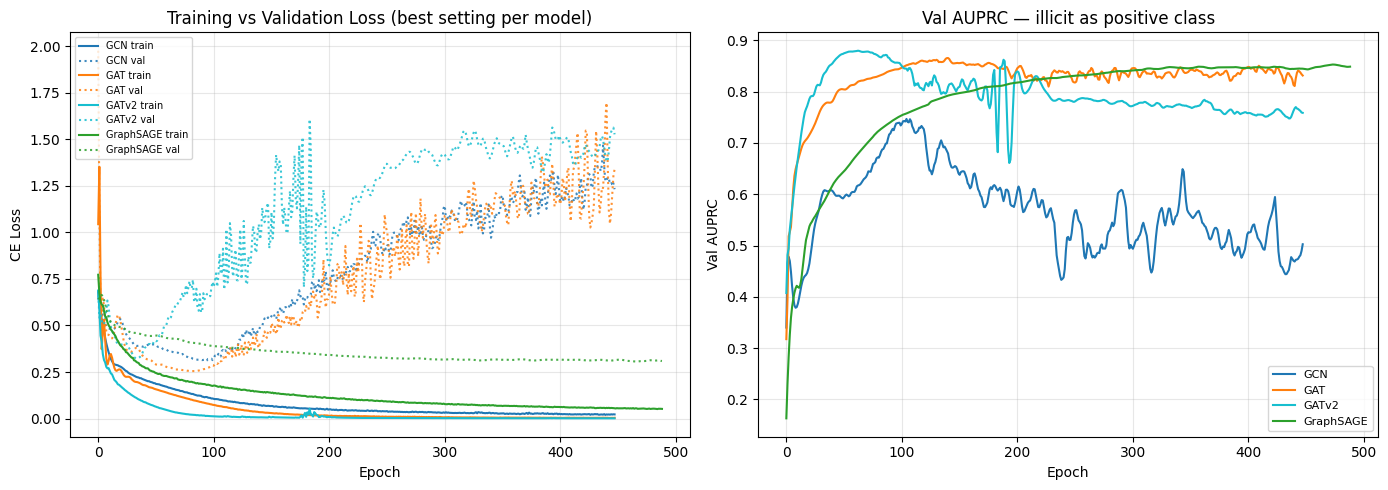

In [ ]:
# ── Best setting per model (by test AUPRC) ──────────────────────────────────
best_settings = {}
for model in MODEL_NAMES:
    best_s, best_v = None, -1
    for s in EXPERIMENT_SETTINGS:
        key = (s, model)
        if key in all_results and all_results[key]['test_auprc'] > best_v:
            best_v = all_results[key]['test_auprc']
            best_s = s
    if best_s: best_settings[model] = best_s

# ── Collect train/val loss and val AUPRC into independent dicts ──────────────
plot_train_losses = {}
plot_val_losses   = {}
plot_val_auprc    = {}

for model in MODEL_NAMES:
    if model not in best_settings:
        continue
    res = all_results[(best_settings[model], model)]

    # train losses
    tl = res.get('train_losses', [])
    if tl:
        plot_train_losses[model] = list(tl)

    # val losses
    vl = res.get('val_losses', [])
    vl_pairs = [(e, v) for e, v in enumerate(vl) if v is not None]
    if vl_pairs:
        plot_val_losses[model] = vl_pairs

    # val AUPRC
    vs = res.get('val_scores', [])
    vs_pairs = [(e, v) for e, v in enumerate(vs) if v is not None]
    if vs_pairs:
        plot_val_auprc[model] = vs_pairs

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for model in MODEL_NAMES:
    color   = COLORS[model]
    display = 'GraphSAGE' if model == 'SAGE' else model

    # Left: train loss (solid)
    if model in plot_train_losses:
        tl = plot_train_losses[model]
        ax1.plot(range(len(tl)), tl,
                 label=f'{display} train', color=color,
                 linewidth=1.5, linestyle='-')

    # Left: val loss (dotted, same colour)
    if model in plot_val_losses:
        epochs, vals = zip(*plot_val_losses[model])
        ax1.plot(epochs, vals,
                 label=f'{display} val', color=color,
                 linewidth=1.5, linestyle=':', alpha=0.85)

    # Right: val AUPRC
    if model in plot_val_auprc:
        epochs, vals = zip(*plot_val_auprc[model])
        ax2.plot(epochs, vals,
                 label=display, color=color, linewidth=1.5)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('CE Loss')
ax1.set_title('Training vs Validation Loss (best setting per model)')
ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val AUPRC')
ax2.set_title('Val AUPRC — illicit as positive class')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


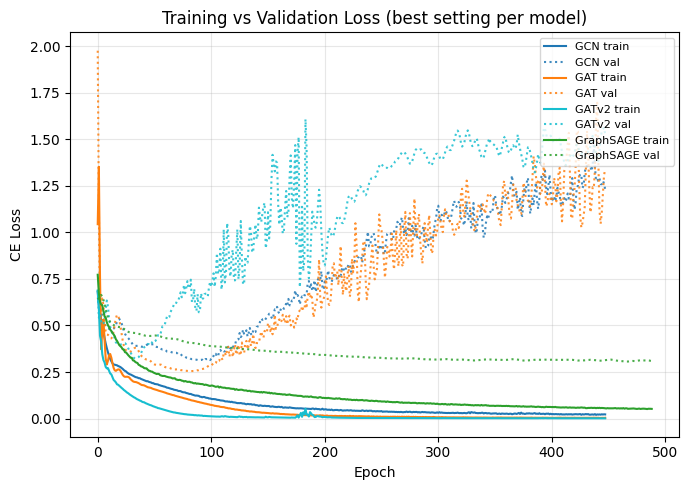

In [ ]:
# ── Plot: Training vs Validation Loss ───────────────────────────────────────
plt.figure(figsize=(7, 5))

for model in MODEL_NAMES:
    color   = COLORS[model]
    display = 'GraphSAGE' if model == 'SAGE' else model

    # Train loss
    if model in plot_train_losses:
        tl = plot_train_losses[model]
        plt.plot(range(len(tl)), tl,
                 label=f'{display} train',
                 color=color, linewidth=1.5, linestyle='-')

    # Val loss
    if model in plot_val_losses:
        epochs, vals = zip(*plot_val_losses[model])
        plt.plot(epochs, vals,
                 label=f'{display} val',
                 color=color, linewidth=1.5, linestyle=':',
                 alpha=0.85)

plt.xlabel('Epoch')
plt.ylabel('CE Loss')
plt.title('Training vs Validation Loss (best setting per model)')

# ✅ legend top-right
plt.legend(fontsize=8, loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

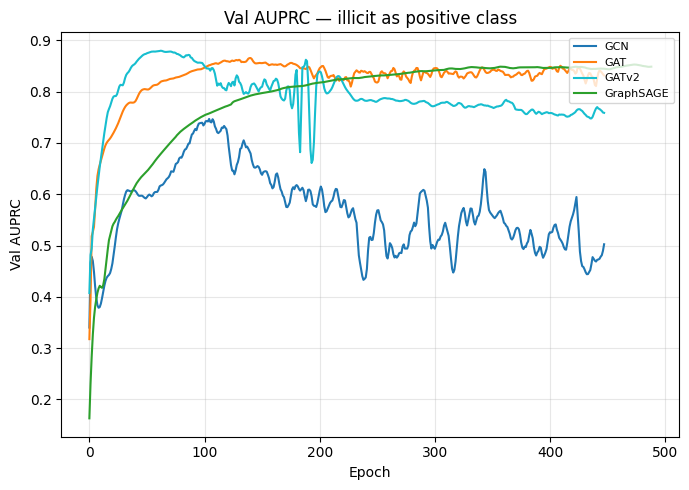

In [ ]:
# ── Plot: Validation AUPRC ─────────────────────────────────────────────────
plt.figure(figsize=(7, 5))

for model in MODEL_NAMES:
    color   = COLORS[model]
    display = 'GraphSAGE' if model == 'SAGE' else model

    if model in plot_val_auprc:
        epochs, vals = zip(*plot_val_auprc[model])
        plt.plot(epochs, vals,
                 label=display,
                 color=color, linewidth=1.5)

plt.xlabel('Epoch')
plt.ylabel('Val AUPRC')
plt.title('Val AUPRC — illicit as positive class')

# ✅ legend top-right
plt.legend(fontsize=8, loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

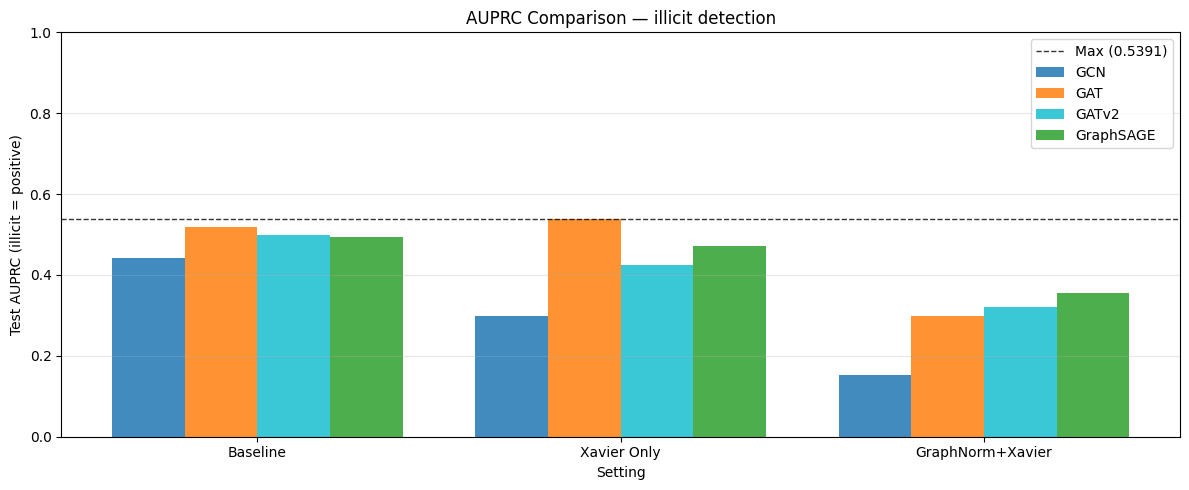

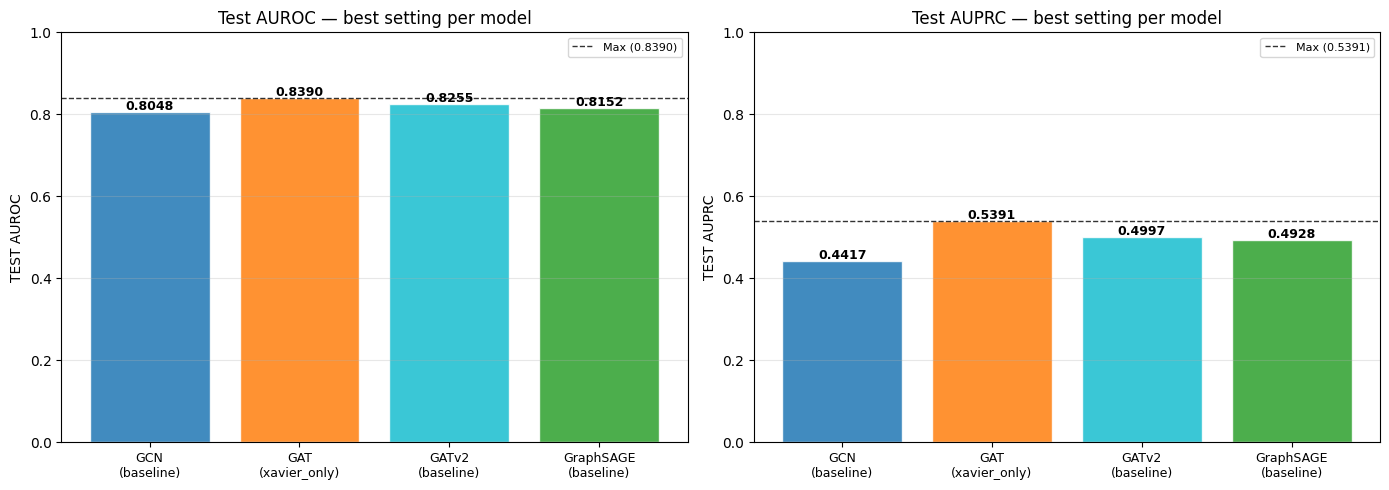

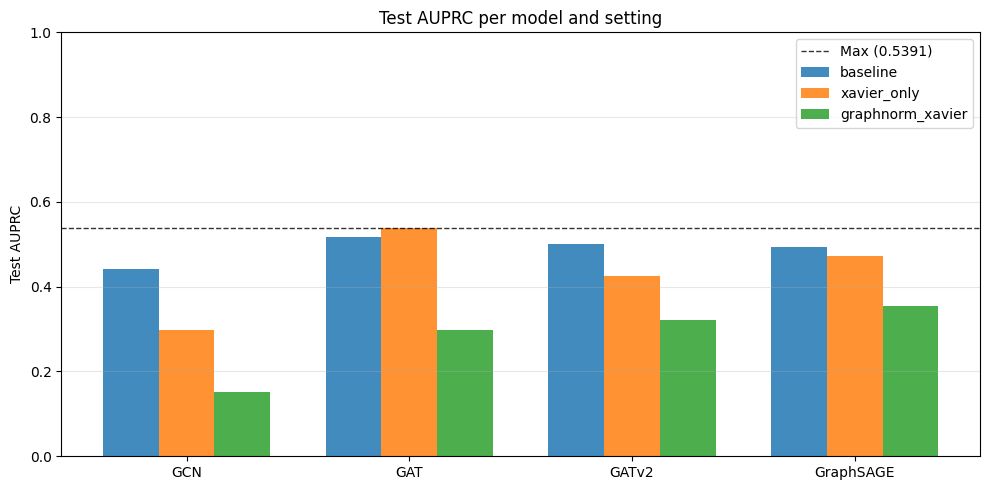

In [ ]:
# ── AUPRC bar chart (all settings per model) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(EXPERIMENT_SETTINGS))
width = 1.0 / (len(MODEL_NAMES) + 1)
_auprc_all = [all_results.get((s, m), {}).get('test_auprc', 0)
              for s in EXPERIMENT_SETTINGS for m in MODEL_NAMES]
_auprc_max = max(_auprc_all) if _auprc_all else 0

for i, model in enumerate(MODEL_NAMES):
    vals = [all_results.get((s, model), {}).get('test_auprc', 0)
            for s in EXPERIMENT_SETTINGS]
    offset = (i - (len(MODEL_NAMES)-1)/2.0) * width
    display = 'GraphSAGE' if model == 'SAGE' else model
    ax.bar(x + offset, vals, width, label=display, color=COLORS[model], alpha=0.85)

ax.axhline(y=_auprc_max, linestyle='--', linewidth=1, alpha=0.8,
           color='black', label=f'Max ({_auprc_max:.4f})')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline', 'Xavier Only', 'GraphNorm+Xavier'])
ax.set_xlabel('Setting'); ax.set_ylabel('Test AUPRC (illicit = positive)')
ax.set_title('AUPRC Comparison — illicit detection')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


# ── Best setting per model (by test AUPRC) ────────────────────────────────────
best_settings = {}
for model in MODEL_NAMES:
    best_s, best_v = None, -1
    for s in EXPERIMENT_SETTINGS:
        key = (s, model)
        if key in all_results and all_results[key]['test_auprc'] > best_v:
            best_v = all_results[key]['test_auprc']
            best_s = s
    if best_s:
        best_settings[model] = best_s

# ── AUROC and AUPRC side by side (best setting per model) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_auroc_best = [all_results[(best_settings[m], m)]['test_auroc']
               for m in MODEL_NAMES if m in best_settings]
_auprc_best = [all_results[(best_settings[m], m)]['test_auprc']
               for m in MODEL_NAMES if m in best_settings]

for ax, metric, vals_all, title in [
    (axes[0], 'test_auroc', _auroc_best, 'Test AUROC — best setting per model'),
    (axes[1], 'test_auprc', _auprc_best, 'Test AUPRC — best setting per model'),
]:
    _max_val = max(vals_all) if vals_all else 0
    vals   = []
    labels = []
    colors = []
    for model in MODEL_NAMES:
        if model not in best_settings:
            continue
        key = (best_settings[model], model)
        vals.append(all_results[key][metric])
        display = 'GraphSAGE' if model == 'SAGE' else model
        labels.append(f'{display}\n({best_settings[model]})')
        colors.append(COLORS[model])
    bars = ax.bar(range(len(vals)), vals, color=colors, alpha=0.85,
                  edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(y=_max_val, linestyle='--', linewidth=1, alpha=0.8,
               color='black', label=f'Max ({_max_val:.4f})')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(metric.replace('_', ' ').upper())
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# ── Test AUPRC per model per setting ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(MODEL_NAMES))
width = 0.25
_auprc_per = [all_results.get((s, m), {}).get('test_auprc', 0)
              for s in EXPERIMENT_SETTINGS for m in MODEL_NAMES]
_auprc_per_max = max(_auprc_per) if _auprc_per else 0

for j, setting in enumerate(EXPERIMENT_SETTINGS):
    vals = [all_results.get((setting, m), {}).get('test_auprc', 0)
            for m in MODEL_NAMES]
    ax.bar(x + (j - 1) * width, vals, width, label=setting, alpha=0.85)

ax.axhline(y=_auprc_per_max, linestyle='--', linewidth=1, alpha=0.8,
           color='black', label=f'Max ({_auprc_per_max:.4f})')
display_names = ['GraphSAGE' if m == 'SAGE' else m for m in MODEL_NAMES]
ax.set_xticks(x)
ax.set_xticklabels(display_names)
ax.set_title('Test AUPRC per model and setting')
ax.set_ylabel('Test AUPRC')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


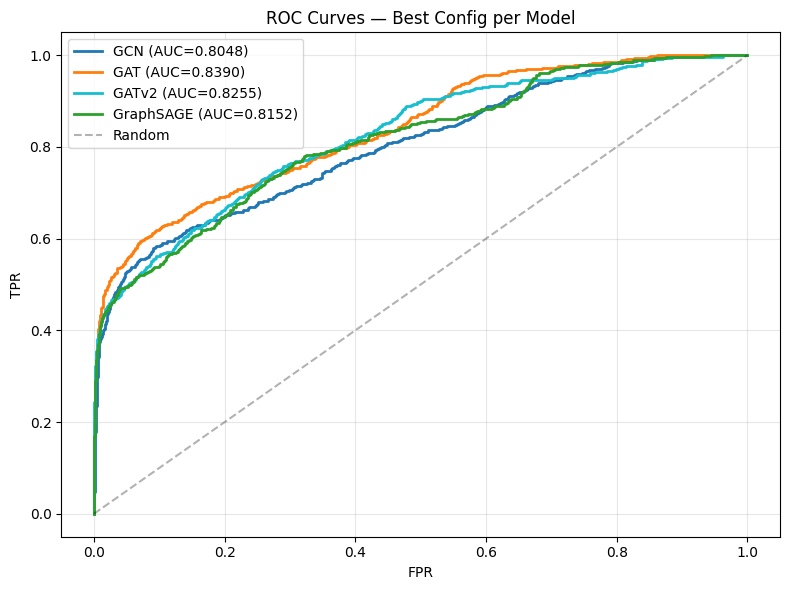

In [ ]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for model in MODEL_NAMES:
    if model not in best_settings: continue
    res = all_results.get((best_settings[model], model))
    if res is None or res['test_probs'] is None: continue
    fpr, tpr, _ = roc_curve(res['test_labels'], res['test_probs'])
    display = 'GraphSAGE' if model == 'SAGE' else model
    ax.plot(fpr, tpr, label=f'{display} (AUC={res["test_auroc"]:.4f})',
            color=COLORS[model], linewidth=2)

ax.plot([0,1],[0,1],'k--',alpha=0.3,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Best Config per Model')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


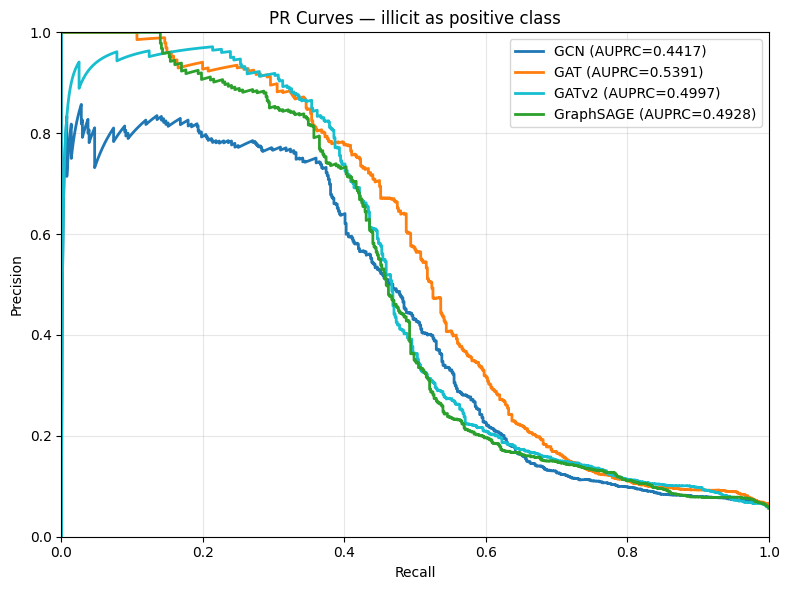

In [ ]:
# ── Precision-Recall curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for model in MODEL_NAMES:
    if model not in best_settings: continue
    res = all_results.get((best_settings[model], model))
    if res is None or res.get('pr_recall') is None: continue
    display = 'GraphSAGE' if model == 'SAGE' else model
    ax.plot(res['pr_recall'], res['pr_prec'],
            label=f'{display} (AUPRC={res["test_auprc"]:.4f})',
            color=COLORS[model], linewidth=2)

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — illicit as positive class')
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Save Results

In [ ]:
# ── Save scalar metrics to CSV ───────────────────────────────────────────────
rows = []
for model in MODEL_NAMES:
    for setting in ['baseline', 'xavier_only', 'graphnorm_xavier']:
        key = (setting, model)
        if key not in all_results: continue
        r = all_results[key]
        p = r['best_params']
        rows.append({
            'Model':         model,
            'Setting':       setting,
            'Test_AUROC':    round(r['test_auroc'], 4),
            'Test_AUPRC':    round(r['test_auprc'], 4),
            'Val_AUPRC':     round(r['val_auprc'],  4),
            'F1_at_90':      round(r['f1_at_90'],   4),
            'F1_at_99':      round(r['f1_at_99'],   4),
            'F1_at_99.9':    round(r.get('f1_at_99.9', 0), 4),
            'Prec_at_90':    round(r['precision_at_90'], 4),
            'Rec_at_90':     round(r['recall_at_90'],    4),
            'LR':            round(p.get('lr', 0), 8),
            'Hidden_dim':    p.get('hidden_dim'),
            'Emb_dim':       p.get('embedding_dim'),
            'Num_layers':    p.get('num_layers'),
            'Dropout':       round(p.get('dropout', 0), 5),
            'N_epochs':      p.get('n_epochs'),
            'Weight_decay':  round(p.get('weight_decay', 0), 7),
            'Aggregator':    p.get('aggregator', '-'),
        })

df = pd.DataFrame(rows)
df.to_csv('results_csv/all_results.csv', index=False)
print(f'Saved {len(rows)} rows to results_csv/all_results.csv')
print(df.to_string(index=False))

# ── Save full results dict (includes curve arrays) ────────────────────────────
with open('results_csv/all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print('\nFull results (curve arrays, per-epoch history) saved to results_csv/all_results.pkl')


Saved 12 rows to results_csv/all_results.csv
Model          Setting  Test_AUROC  Test_AUPRC  Val_AUPRC  F1_at_90  F1_at_99  F1_at_99.9  Prec_at_90  Rec_at_90       LR  Hidden_dim  Emb_dim  Num_layers  Dropout  N_epochs  Weight_decay Aggregator
  GCN         baseline      0.8048      0.4417     0.7467    0.4023    0.2460      0.0278      0.3155     0.5550 0.000829         239      103           3  0.08350       448      0.000043          -
  GCN      xavier_only      0.8185      0.2984     0.6452    0.3293    0.1872      0.0093      0.2583     0.4544 0.000263         145       82           2  0.20652       204      0.000349          -
  GCN graphnorm_xavier      0.7556      0.1516     0.4239    0.2507    0.0267      0.0093      0.1966     0.3459 0.000520         151      127           3  0.56434       358      0.005829          -
  GAT         baseline      0.8323      0.5177     0.8537    0.4057    0.2701      0.0370      0.3181     0.5597 0.000829         239      103           3  0.0